In [2]:
import time
import importlib
import numpy as np
import sys
import urllib.request
import matplotlib.pyplot as plt
sys.path.append('../')
import deep_learning.model
import idx2numpy # pip install idx2numpy
import gzip
import shutil
from pathlib import Path
#importlib.reload(deep_learning.model)
#importlib.reload(deep_learning.utils)
from deep_learning.utils import train_test_split,to_one_hot,plot_learning_curve,plot_neuron_heatmap
from deep_learning.model import SequentialNetwork,Dense,Softmax,CrossEntropy,ReLU,Convolution2D,Flatten # import my implmentation
from sklearn.datasets import load_digits

In [3]:
digits = load_digits()
digits.images.shape

(1797, 8, 8)

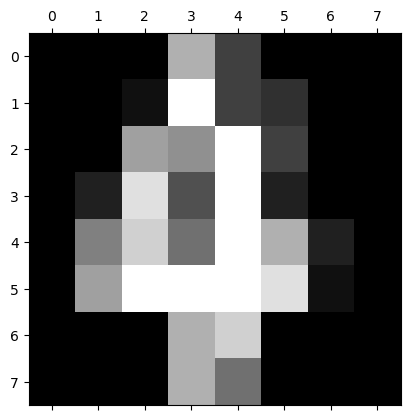

In [4]:
plt.matshow(digits.images[400], cmap="gray")

In [5]:
X=digits.images
y=digits.target
#digits.target_names  


In [6]:
SEED = 24
(X_train, X_test, y_train, y_test) = train_test_split(X, y, 0.1, SEED)
X_train=X_train.reshape(X_train.shape[0], 1, X_train.shape[1], X_train.shape[2]) # adding channel dimension
X_test=X_test.reshape(X_test.shape[0], 1, X_test.shape[1], X_test.shape[2]) # adding channel dimension

In [7]:
# normalization
X_max = np.max(X_train)
X_train = (X_train) / (X_max)
X_test = (X_test ) / (X_max)


In [8]:
y_train_one_hot=to_one_hot(y_train,10)
y_test_one_hot=to_one_hot(y_test,10)

In [9]:
X_train.shape

(1618, 1, 8, 8)

In [10]:
#subgroup=1618#X_train.shape[0]
#sub_X_train = X_train[0:subgroup] 
#sub_y_train = y_train_one_hot[0:subgroup]

In [14]:
importlib.reload(deep_learning.model)
importlib.reload(deep_learning.utils)
from deep_learning.model import SequentialNetwork,Dense,Softmax,CrossEntropy,ReLU,Convolution2D,AVGPooling,Flatten # import my implmentation
EPOCHS = 60
LR = 0.02

# CNN
model = SequentialNetwork(layers=[
    Convolution2D(kernel_size=(3,3),n_kernels=16, input_shape=(1,8,8), stride=1, padding=1, activation_function=ReLU(), lr=LR, seed=SEED), #Output (16,8,8)
    Flatten(),
    Dense(inputs=1024, neurons=64, activation_function=ReLU(), lr=LR, seed=SEED),
    Dense(inputs=64, neurons=10, activation_function=Softmax(), lr=LR, seed=SEED)
], loss_function=CrossEntropy())



Convolutional 2D layer with: 160 trainable parameters, 1024 neurons, 10240 connections, Input: (1, 8, 8),  Output: (16, 8, 8)
Flatten layer
Dense layer with: 65600 trainable parameters, 64 neurons, 65600 connections
Dense layer with: 650 trainable parameters, 10 neurons, 650 connections


In [15]:

start = time.perf_counter()
BATCH_SIZE=64#len(X_train)
n_batches = len(X_train) / BATCH_SIZE
for epoch in range(EPOCHS):
    epoch_loss = model._train_one_epoch(X_train,y_train_one_hot, BATCH_SIZE,False) # 
     #train and test evaluation
    train_preds = np.argmax(model.predict(X_train), axis=1)
    test_preds  = np.argmax(model.predict(X_test), axis=1)
    train_acc   = np.mean(train_preds == y_train)  
    test_acc    = np.mean(test_preds  == y_test)

    print(f"Epoch: {epoch+1} | Loss: {epoch_loss}  Loss/batch: {epoch_loss / n_batches} | Train acc: {train_acc:.2%} | Test acc: {test_acc:.2%}") #first loss/n_batches should be  2.3 — tha is log(10)
 
loss=model.losses
end = time.perf_counter()
print(f"Elapsed time: {end - start} seconds")

Epoch: 1 | Loss: 57.48444784097899  Loss/batch: 2.273797689630813 | Train acc: 53.15% | Test acc: 53.63%
Epoch: 2 | Loss: 49.53981960508722  Loss/batch: 1.9595478706585796 | Train acc: 74.29% | Test acc: 75.42%
Epoch: 3 | Loss: 40.24316543882342  Loss/batch: 1.5918186576543256 | Train acc: 82.39% | Test acc: 83.24%
Epoch: 4 | Loss: 30.5649107191045  Loss/batch: 1.2089952323996835 | Train acc: 86.46% | Test acc: 88.83%
Epoch: 5 | Loss: 22.714856960275714  Loss/batch: 0.8984863074521914 | Train acc: 89.18% | Test acc: 89.94%
Epoch: 6 | Loss: 17.37267085555229  Loss/batch: 0.6871761030626369 | Train acc: 90.11% | Test acc: 91.06%
Epoch: 7 | Loss: 13.906283734470831  Loss/batch: 0.5500631390643592 | Train acc: 91.29% | Test acc: 93.85%
Epoch: 8 | Loss: 11.585893838883411  Loss/batch: 0.4582801024032993 | Train acc: 92.27% | Test acc: 94.41%
Epoch: 9 | Loss: 9.942117373119707  Loss/batch: 0.39326051414070534 | Train acc: 93.08% | Test acc: 94.97%
Epoch: 10 | Loss: 8.713785465389158  Loss/ba

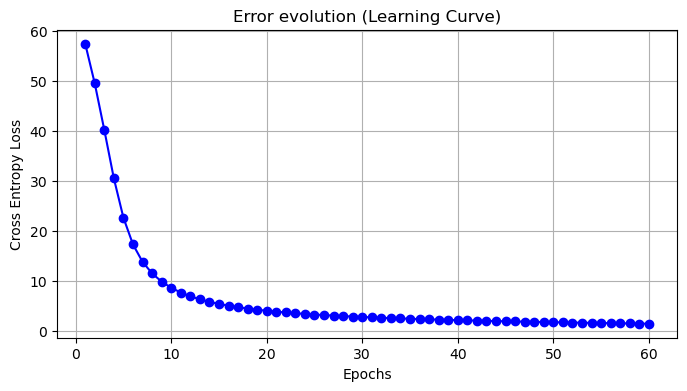

In [280]:
plot_learning_curve(loss, ylabel='Cross Entropy Loss')

In [281]:
probs = model.predict(X_test)      
preds=np.argmax(probs,axis=1)

In [282]:
preds

array([4, 7, 5, 4, 6, 4, 4, 3, 4, 1, 3, 0, 3, 5, 4, 1, 3, 4, 4, 3, 4, 8, 2, 6, 2, 0, 9, 5, 9, 5, 0,
       7, 5, 5, 8, 2, 5, 3, 1, 7, 4, 9, 2, 0, 5, 2, 4, 8, 1, 1, 5, 1, 1, 3, 0, 6, 0, 6, 2, 2, 5, 4,
       2, 1, 9, 0, 2, 3, 4, 8, 9, 9, 9, 3, 9, 1, 3, 1, 4, 0, 1, 3, 5, 1, 3, 5, 7, 9, 6, 9, 6, 7, 5,
       7, 2, 1, 3, 7, 8, 1, 4, 3, 4, 8, 4, 6, 6, 9, 8, 9, 8, 9, 1, 1, 3, 8, 0, 8, 0, 6, 1, 0, 6, 0,
       5, 4, 0, 8, 4, 6, 8, 1, 3, 6, 1, 2, 9, 3, 3, 4, 9, 6, 1, 5, 4, 9, 8, 5, 4, 7, 4, 1, 6, 6, 4,
       6, 2, 8, 6, 8, 7, 8, 5, 1, 2, 7, 5, 7, 6, 9, 8, 2, 3, 7, 8, 7, 4, 4, 1])

In [283]:
y_test

array([4, 7, 5, 4, 6, 4, 4, 3, 4, 1, 3, 0, 3, 5, 4, 6, 3, 4, 4, 3, 4, 8, 2, 6, 2, 0, 9, 5, 9, 5, 0,
       7, 5, 5, 8, 2, 5, 3, 8, 7, 4, 9, 2, 0, 5, 2, 4, 8, 1, 1, 5, 1, 1, 3, 0, 6, 0, 6, 2, 2, 5, 4,
       2, 1, 9, 0, 2, 3, 4, 8, 9, 9, 9, 3, 9, 1, 3, 1, 4, 0, 1, 3, 5, 1, 3, 5, 7, 9, 6, 9, 6, 7, 5,
       7, 2, 1, 3, 7, 8, 1, 4, 3, 4, 8, 4, 6, 6, 9, 8, 9, 8, 9, 1, 1, 3, 8, 0, 8, 0, 6, 1, 0, 6, 0,
       5, 4, 8, 8, 4, 6, 8, 1, 3, 6, 1, 2, 9, 3, 3, 4, 9, 6, 1, 5, 4, 9, 8, 5, 4, 7, 4, 1, 6, 6, 4,
       6, 2, 8, 6, 8, 7, 8, 5, 1, 2, 4, 5, 7, 6, 9, 8, 2, 3, 7, 8, 7, 4, 4, 1])

In [284]:
#for  pred, yi in zip( preds, test_labels):
#    print(f"true: {int(yi)}  prediction: {pred} ")

accuracy = np.mean(preds == y_test)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 97.77%
